In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_codes_incl_temp_incl.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_codes_incl_temp_incl.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [3]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold in case the csv was cleaned with a different threshold
CV_filtered_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (10429072, 17)


In [4]:
#counting days measured per year per station
filtered_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'filtered_days'})
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             97
1  BAKERSFIELD AP  1929            270
2  BAKERSFIELD AP  1930             97
3  BAKERSFIELD AP  1931            255
4  BAKERSFIELD AP  1932            366


In [5]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

23 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'CHICO ARMY FLYING SCHOOL', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'MARYSVILLE AIRPORT (ASOS)', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO 5 ESE', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


In [6]:
# Monthly data coverage (%) by station-year-month using CV_rows
# Coverage is based on unique hourly timestamps in each month:
# coverage_pct = observed_unique_hours / expected_hours_in_month * 100

cv_cov = CV_rows[["STATION", "DATE"]].copy()
cv_cov["DATE"] = pd.to_datetime(cv_cov["DATE"], errors="coerce")
cv_cov = cv_cov.dropna(subset=["DATE"])

# Count unique hours to avoid multiple records within the same hour
cv_cov["hour_ts"] = cv_cov["DATE"].dt.floor("h")
cv_cov = cv_cov.drop_duplicates(subset=["STATION", "hour_ts"])

cv_cov["year"] = cv_cov["hour_ts"].dt.year
cv_cov["month"] = cv_cov["hour_ts"].dt.month

monthly_coverage = (
    cv_cov.groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "observed_hours"})
)

monthly_coverage["month_start"] = pd.to_datetime(
    dict(year=monthly_coverage["year"], month=monthly_coverage["month"], day=1)
)
monthly_coverage["expected_hours"] = monthly_coverage["month_start"].dt.days_in_month * 24
monthly_coverage["coverage_pct"] = (
    monthly_coverage["observed_hours"] / monthly_coverage["expected_hours"] * 100
)

print(monthly_coverage.head(12))
print("Rows:", monthly_coverage.shape[0])

           STATION  year  month  observed_hours month_start  expected_hours  \
0   BAKERSFIELD AP  1928      1              35  1928-01-01             744   
1   BAKERSFIELD AP  1928      9              16  1928-09-01             720   
2   BAKERSFIELD AP  1928     10             206  1928-10-01             744   
3   BAKERSFIELD AP  1928     11             210  1928-11-01             720   
4   BAKERSFIELD AP  1928     12             217  1928-12-01             744   
5   BAKERSFIELD AP  1929      1             200  1929-01-01             744   
6   BAKERSFIELD AP  1929      2             196  1929-02-01             672   
7   BAKERSFIELD AP  1929      3             217  1929-03-01             744   
8   BAKERSFIELD AP  1929      4             210  1929-04-01             720   
9   BAKERSFIELD AP  1929      5             217  1929-05-01             744   
10  BAKERSFIELD AP  1929      6             210  1929-06-01             720   
11  BAKERSFIELD AP  1929      7             431  192

C:\Users\Work Account\AppData\Local\Temp\ipykernel_2124\2450530249.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


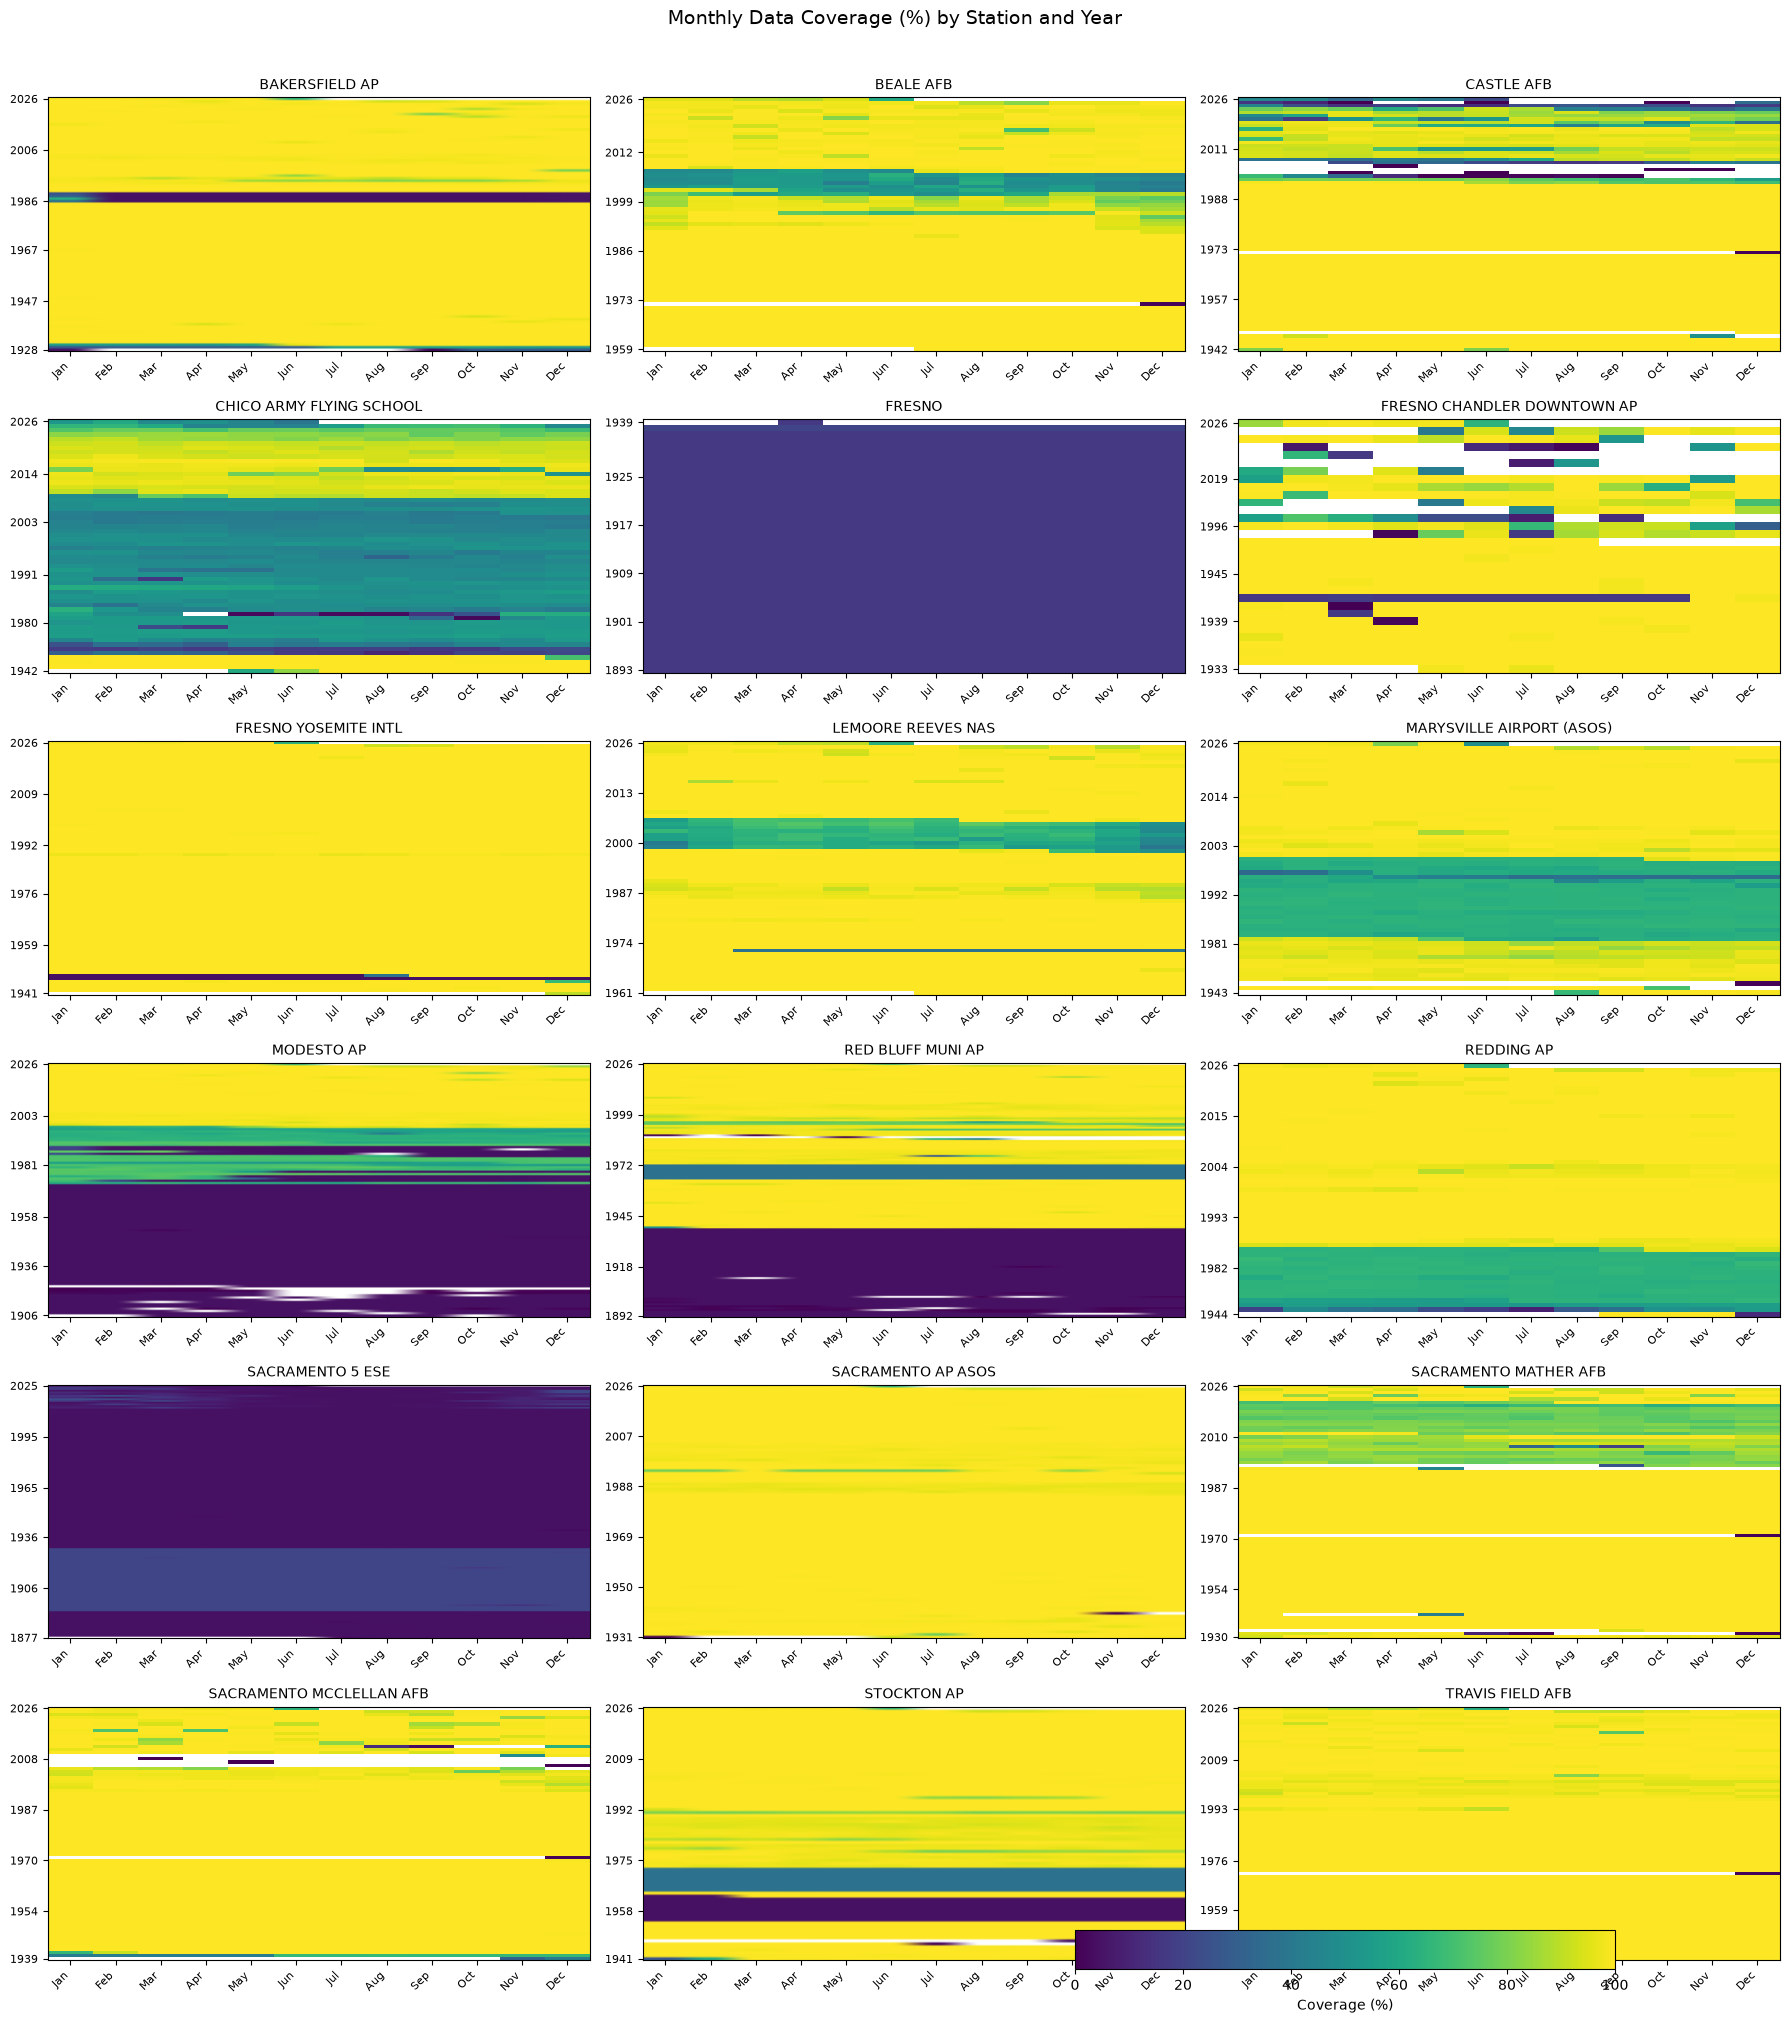

In [7]:
# Plot: one heatmap per station (year x month)
stations_cov = sorted(monthly_coverage["STATION"].unique())
# use stations with data back to at least 1970
stations_cov = [st for st in stations_cov if st in stations_pre1970]
#exclude stations with less than 10 years of data
stations_cov = [st for st in stations_cov if monthly_coverage[monthly_coverage["STATION"] == st]["year"].nunique() >= 10]
n_stations = len(stations_cov)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.3))
axes = np.array(axes).reshape(-1)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

for i, st in enumerate(stations_cov):
    ax = axes[i]
    st_df = monthly_coverage[monthly_coverage["STATION"] == st]
    pivot = (
        st_df.pivot(index="year", columns="month", values="coverage_pct")
        .reindex(columns=range(1, 13))
        .sort_index()
    )

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=100,
        cmap="viridis"
    )

    ax.set_title(st, fontsize=10)
    ax.set_xticks(np.arange(12))
    ax.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)

    if len(pivot.index) > 0:
        y_idx = np.linspace(0, len(pivot.index) - 1, min(6, len(pivot.index))).astype(int)
        ax.set_yticks(y_idx)
        ax.set_yticklabels(pivot.index[y_idx], fontsize=8)
    else:
        ax.set_yticks([])

for ax in axes[n_stations:]:
    fig.delaxes(ax)

#make color bar at the bottom right of the figures
cax = fig.add_axes([0.6, 0.02, 0.3, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation="horizontal",fraction=0.02, pad=0.04)
cbar.set_label("Coverage (%)")

fig.suptitle("Monthly Data Coverage (%) by Station and Year", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_2124\701291493.py:28: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
C:\Users\Work Account\AppData\Local\Temp\ipykernel_2124\701291493.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


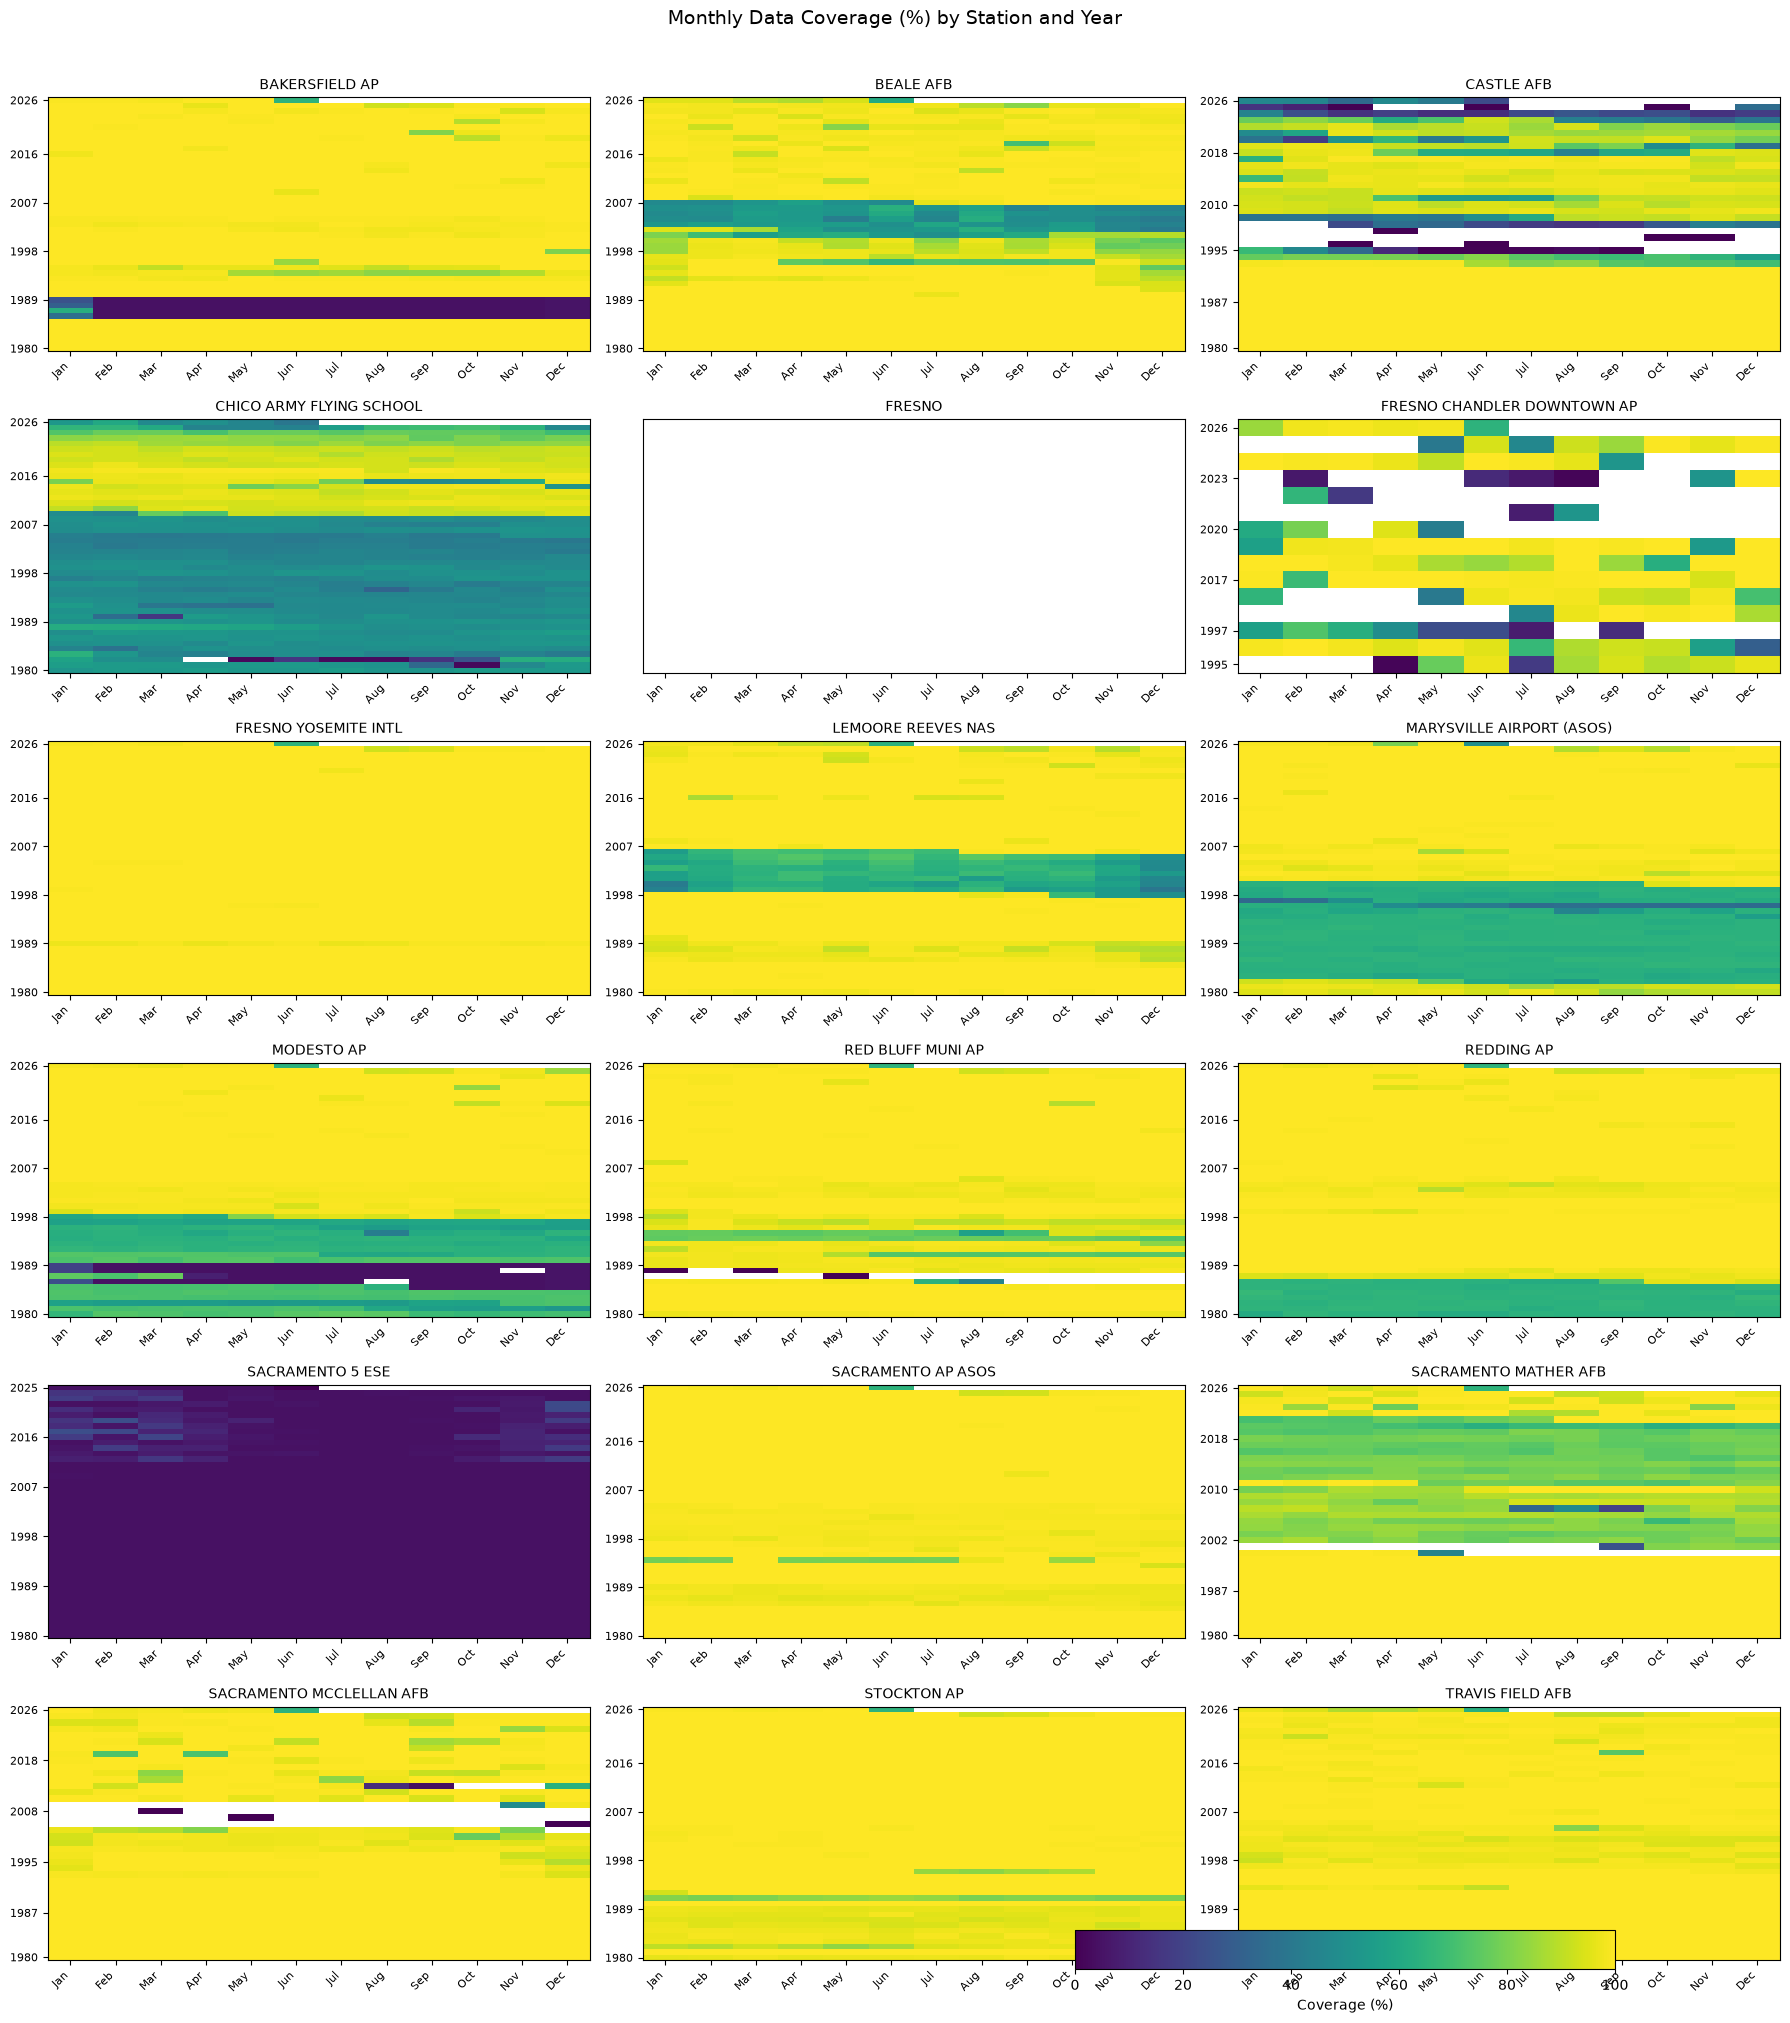

In [8]:

# Plot: one heatmap per station (year x month)
stations_cov = sorted(monthly_coverage["STATION"].unique())
# use stations with data back to at least 1970
stations_cov = [st for st in stations_cov if st in stations_pre1970]
#exclude stations with less than 10 years of data
stations_cov = [st for st in stations_cov if monthly_coverage[monthly_coverage["STATION"] == st]["year"].nunique() >= 10]
n_stations = len(stations_cov)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.3))
axes = np.array(axes).reshape(-1)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

for i, st in enumerate(stations_cov):
    ax = axes[i]
    st_df = monthly_coverage[monthly_coverage["STATION"] == st]
    #only plot years since 1980
    st_df = st_df[st_df["year"] >= 1980]
    pivot = (
        st_df.pivot(index="year", columns="month", values="coverage_pct")
        .reindex(columns=range(1, 13))
        .sort_index()
    )

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=100,
        cmap="viridis"
    )

    ax.set_title(st, fontsize=10)
    ax.set_xticks(np.arange(12))
    ax.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)

    if len(pivot.index) > 0:
        y_idx = np.linspace(0, len(pivot.index) - 1, min(6, len(pivot.index))).astype(int)
        ax.set_yticks(y_idx)
        ax.set_yticklabels(pivot.index[y_idx], fontsize=8)
    else:
        ax.set_yticks([])

for ax in axes[n_stations:]:
    fig.delaxes(ax)

#make color bar at the bottom right of the figures
cax = fig.add_axes([0.6, 0.02, 0.3, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation="horizontal",fraction=0.02, pad=0.04)
cbar.set_label("Coverage (%)")

fig.suptitle("Monthly Data Coverage (%) by Station and Year", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Station-year coverage based on total observed vs expected hours in each year
station_year_coverage = (
    monthly_coverage
    .groupby(["STATION", "year"], as_index=False)[["observed_hours", "expected_hours"]]
    .sum()
)

station_year_coverage["coverage_pct"] = (
    station_year_coverage["observed_hours"] / station_year_coverage["expected_hours"] * 100
)

# Keep only station-year periods with >= 90% coverage
station_year_cov90 = station_year_coverage.loc[
    station_year_coverage["coverage_pct"] >= 90
].sort_values(["STATION", "year"]).reset_index(drop=True)

print("Station-year periods with >=90% coverage:", station_year_cov90.shape)
station_year_cov90.head()

Station-year periods with >=90% coverage: (1178, 5)


,STATION,year,observed_hours,expected_hours,coverage_pct
0,BAKERSFIELD AP,1931,8758,8760,99.977169
1,BAKERSFIELD AP,1932,8780,8784,99.954463
2,BAKERSFIELD AP,1933,8758,8760,99.977169
3,BAKERSFIELD AP,1934,8752,8760,99.908676
4,BAKERSFIELD AP,1935,8753,8760,99.920091


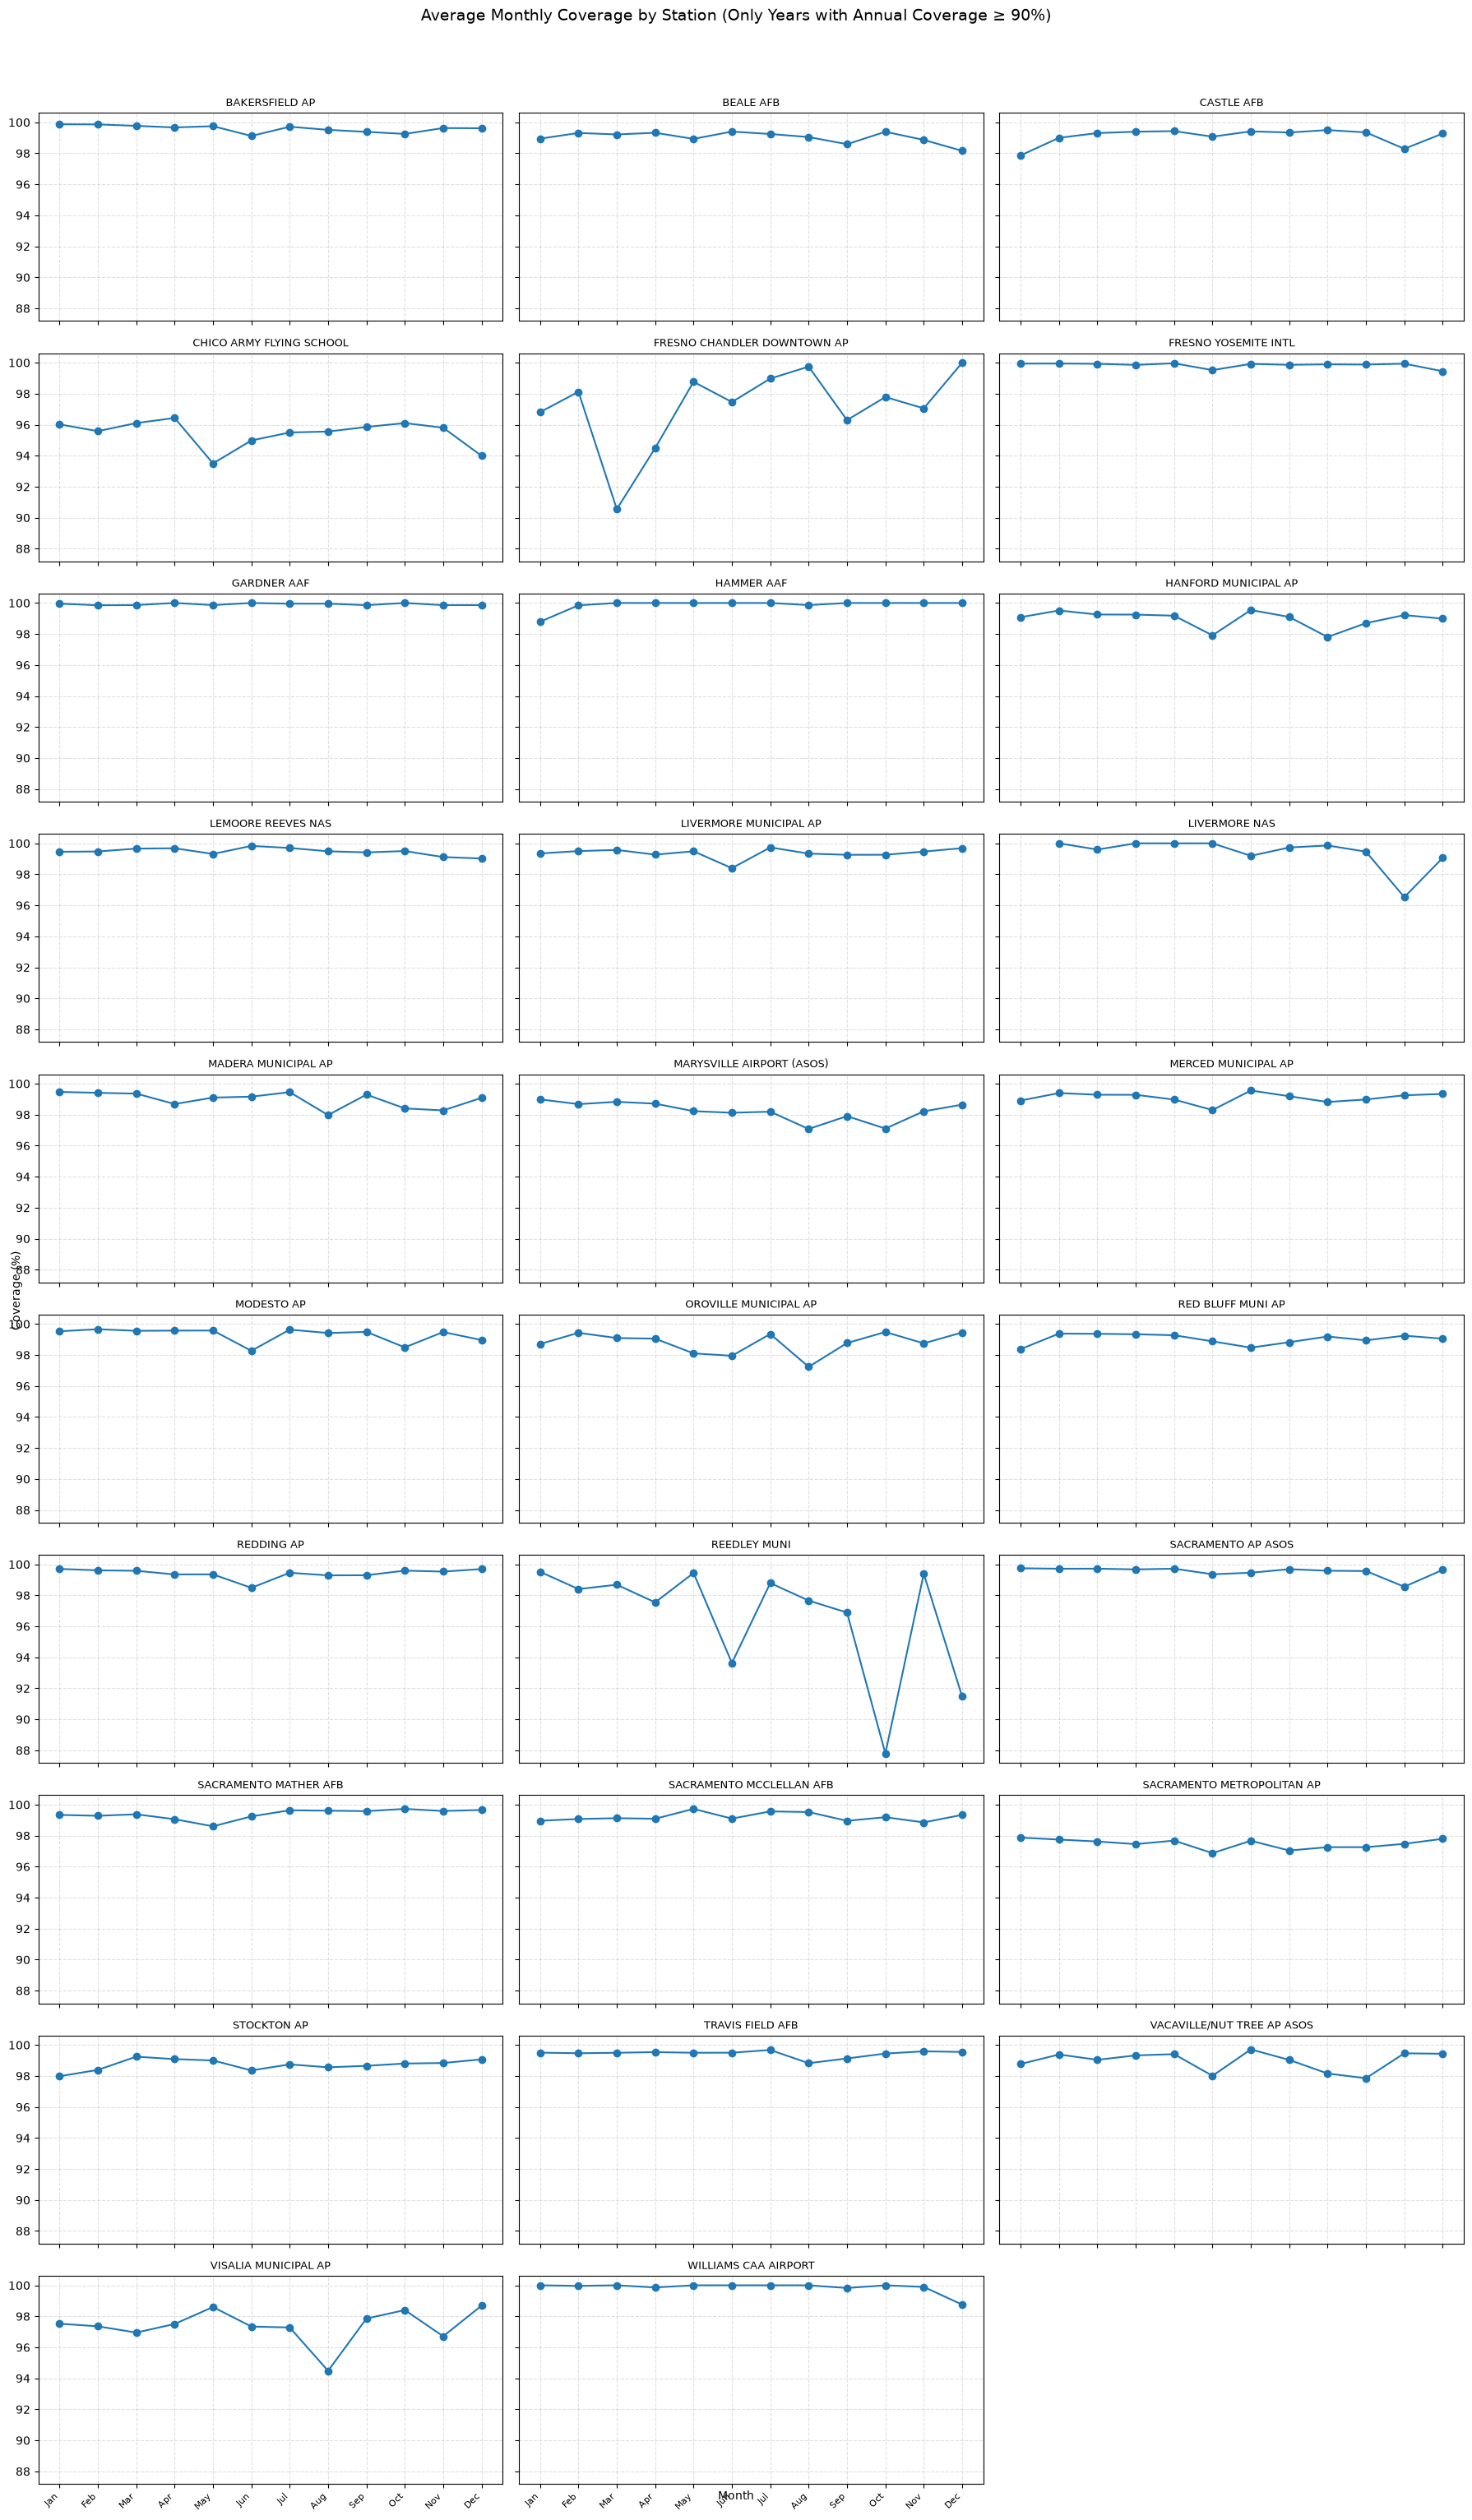

In [10]:
# Keep only station-year combinations with >=90% annual coverage
eligible_station_years = station_year_cov90[["STATION", "year"]].drop_duplicates()

# Monthly coverage restricted to eligible years
monthly_cov_90yr = monthly_coverage.merge(
    eligible_station_years,
    on=["STATION", "year"],
    how="inner"
)

# Average monthly coverage by station (across eligible years)
monthly_cov_90yr_summary = (
    monthly_cov_90yr
    .groupby(["STATION", "month"], as_index=False)["coverage_pct"]
    .mean()
    .sort_values(["STATION", "month"])
)

stations_plot = sorted(monthly_cov_90yr_summary["STATION"].unique())
n_stations = len(stations_plot)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, st in enumerate(stations_plot):
    ax = axes[i]
    st_df = monthly_cov_90yr_summary[monthly_cov_90yr_summary["STATION"] == st].set_index("month").reindex(range(1, 13))
    
    ax.plot(range(1, 13), st_df["coverage_pct"], marker="o", linewidth=1.5, color="tab:blue")
    ax.set_title(st, fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Monthly Coverage by Station (Only Years with Annual Coverage ≥ 90%)", fontsize=14, y=1.02)
fig.text(0.5, 0.01, "Month", ha="center")
fig.text(0.01, 0.5, "Coverage (%)", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

In [12]:
# Keep only station-year periods with >=90% annual coverage from CV_rows
CV_rows_cov90 = CV_rows.merge(
    eligible_station_years,
    on=["STATION", "year"],
    how="inner"
)

print("Original CV_rows shape:", CV_rows.shape)
print("Filtered CV_rows_cov90 shape:", CV_rows_cov90.shape)
CV_rows_cov90.head()

Original CV_rows shape: (14495835, 17)
Filtered CV_rows_cov90 shape: (12582388, 17)


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,HourlyVisibility,year,month,day,hour,minute,STATION
0,USM00074917,35.117,-119.3,1941-12-01 00:00:00,SAO,11.9,13.0,0.0,||00,BKN:06,16.093,1941,12,1,0,0,GARDNER AAF
1,USM00074917,35.117,-119.3,1941-12-01 01:00:00,SAO,10.7,12.4,0.0,||00,OVC:08,16.093,1941,12,1,1,0,GARDNER AAF
2,USM00074917,35.117,-119.3,1941-12-01 02:00:00,SAO,11.3,12.4,0.0,||00,OVC:08,16.093,1941,12,1,2,0,GARDNER AAF
3,USM00074917,35.117,-119.3,1941-12-01 03:00:00,SAO,11.3,12.4,0.0,||00,OVC:08,16.093,1941,12,1,3,0,GARDNER AAF
4,USM00074917,35.117,-119.3,1941-12-01 04:00:00,SAO,11.9,13.0,0.0,||00,OVC:08,16.093,1941,12,1,4,0,GARDNER AAF


In [14]:
# save CV_rows_cov90 to CSV
CV_rows_cov90.to_csv('CV_rows_cov90.csv', index=False)

In [ ]:
# Keep only station-year periods with at least 90% data coverage
valid_months_90 = monthly_coverage.loc[
    monthly_coverage["coverage_pct"] >= 90, ["STATION", "year", "month"]
].drop_duplicates()

# Apply coverage filter to fog rows
CV_filtered_rows_cov90 = CV_filtered_rows.merge(
    valid_months_90,
    on=["STATION", "year", "month"],
    how="inner"
)

print("Original CV_filtered_rows shape:", CV_filtered_rows.shape)
print("Filtered CV_filtered_rows_cov90 shape:", CV_filtered_rows_cov90.shape)
CV_filtered_rows_cov90.head()

Original CV_filtered_rows shape: (10429072, 14)
Filtered CV_filtered_rows_cov90 shape: (9472144, 14)


,STATION_ID,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
0,USM00074917,35.117,-119.3,1941-12-01 00:00:00,0.0,16.093,0.0,0.0,1941,12,1,0,0,GARDNER AAF
1,USM00074917,35.117,-119.3,1941-12-01 01:00:00,0.0,16.093,158.0,0.5,1941,12,1,1,0,GARDNER AAF
2,USM00074917,35.117,-119.3,1941-12-01 02:00:00,0.0,16.093,0.0,0.0,1941,12,1,2,0,GARDNER AAF
3,USM00074917,35.117,-119.3,1941-12-01 03:00:00,0.0,16.093,225.0,0.5,1941,12,1,3,0,GARDNER AAF
4,USM00074917,35.117,-119.3,1941-12-01 04:00:00,0.0,16.093,225.0,0.5,1941,12,1,4,0,GARDNER AAF


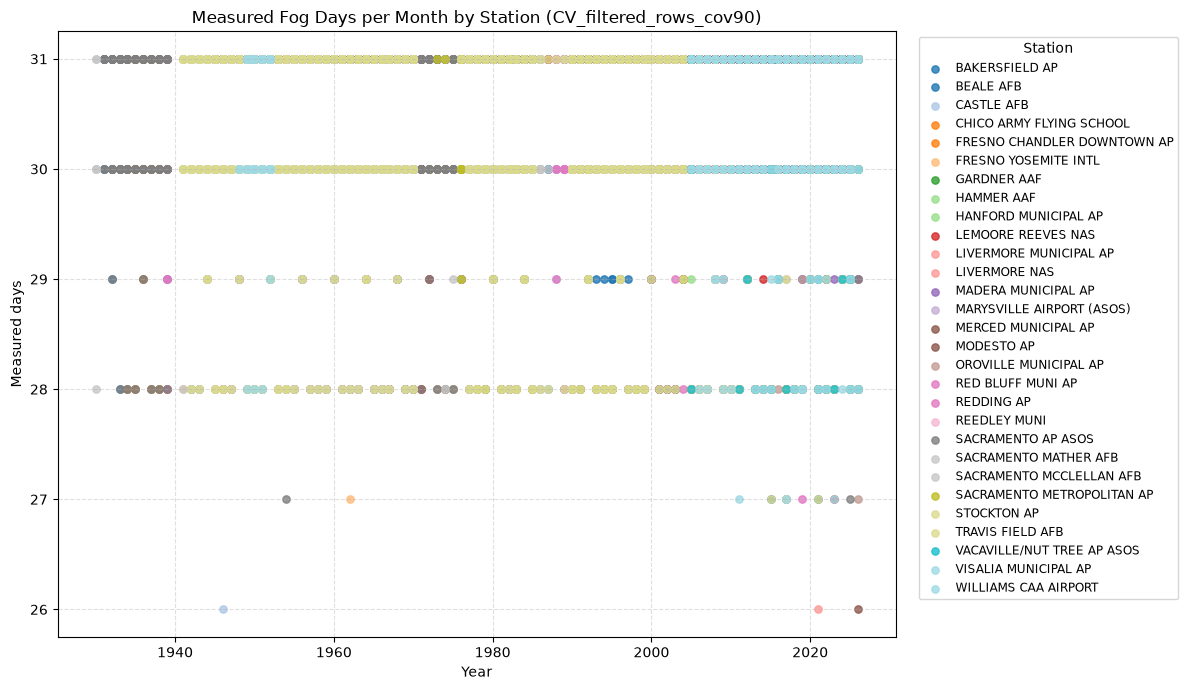

In [10]:
# Count measured fog days per station-year from CV_filtered_rows_cov90
measured_days_year_cov90 = (
    CV_filtered_rows_cov90
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "measured_days"})
    .sort_values(["STATION", "year", "month"])
)

# Plot with one color per station
stations_cov90 = sorted(measured_days_year_cov90["STATION"].unique())
station_colors_cov90 = dict(zip(stations_cov90, plt.cm.tab20(np.linspace(0, 1, len(stations_cov90)))))

fig, ax = plt.subplots(figsize=(12, 7))

for st in stations_cov90:
    st_df = measured_days_year_cov90[measured_days_year_cov90["STATION"] == st]
    ax.scatter(
        st_df["year"],
        st_df["measured_days"],
        s=28,
        alpha=0.8,
        color=station_colors_cov90[st],
        label=st
    )

ax.set_title("Measured Fog Days per Month by Station (CV_filtered_rows_cov90)")
ax.set_xlabel("Year")
ax.set_ylabel("Measured days")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")
plt.tight_layout()
plt.show()

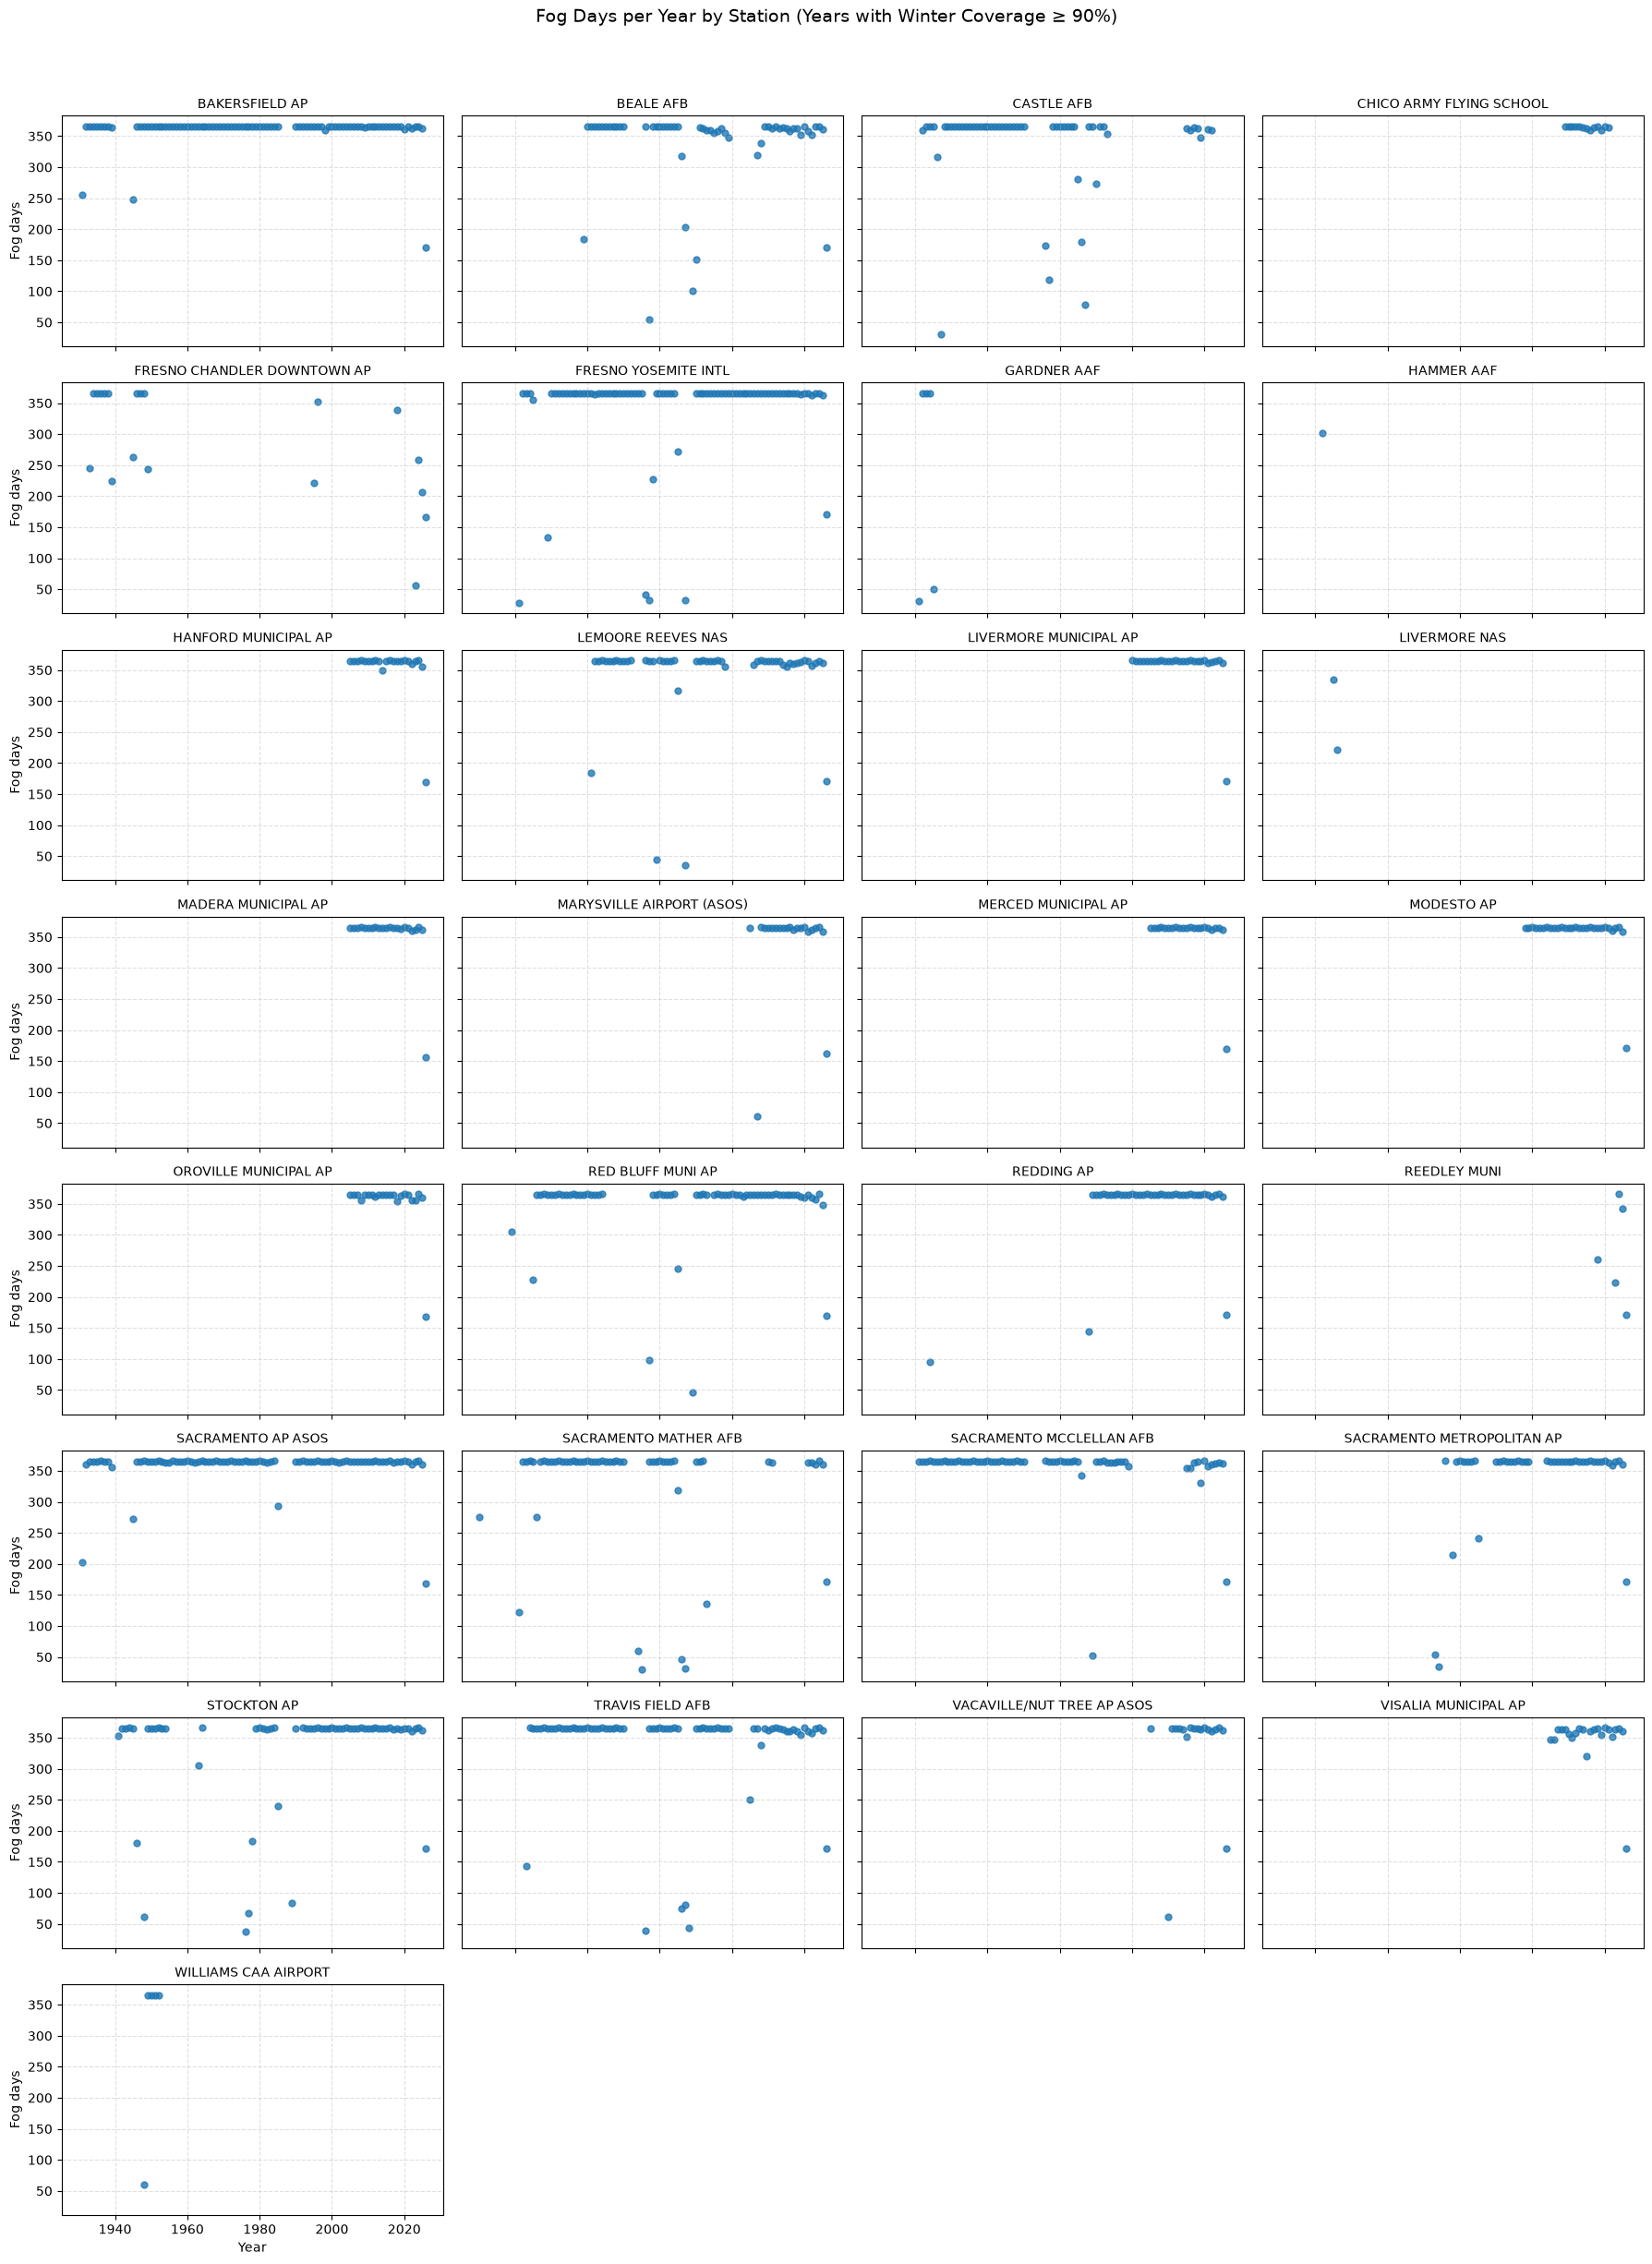

Stations included: 29
Total year-station combinations: 1077


In [12]:
# Create scatterplots for each station showing fog days per year
# Including years that have at least one winter month (Nov-Mar) with >= 90% coverage

# First, identify valid years per station based on winter month coverage
winter_months = [11, 12, 1, 2, 3]
valid_years_winter = (
    monthly_coverage[
        (monthly_coverage["month"].isin(winter_months)) & 
        (monthly_coverage["coverage_pct"] >= 90)
    ]
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .drop(columns="size")
)

# Merge with fog_days_year to include only years with winter coverage
filtered_days_year_winter_cov = (
    filtered_days_year
    .merge(valid_years_winter, on=["STATION", "year"], how="inner")
    .sort_values(["STATION", "year"])
)

# Create scatterplots
stations = sorted(filtered_days_year_winter_cov["STATION"].unique())
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = filtered_days_year_winter_cov[filtered_days_year_winter_cov["STATION"] == station].sort_values("year")
    
    ax.scatter(station_df["year"], station_df["filtered_days"], s=25, alpha=0.8, color="tab:blue")
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    
    if idx % ncols == 0:
        ax.set_ylabel("Fog days")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Fog Days per Year by Station (Years with Winter Coverage ≥ 90%)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Stations included: {len(stations)}")
print(f"Total year-station combinations: {len(filtered_days_year_winter_cov)}")